In [58]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

import xgboost as xgb
df = pd.read_csv("../data/filteredvehpub.csv")   # adjust path as needed
df.head()
df.shape

(256115, 13)

In [60]:
df.columns

Index(['HOUSEID', 'HHFAMINC', 'HHSIZE', 'LIF_CYC', 'CENSUS_R', 'URBAN',
       'VEHID', 'DRVRCNT', 'MAKE', 'HH_RACE', 'WRKCOUNT', 'HOMEOWN',
       'URBANSIZE'],
      dtype='object')

In [62]:
import numpy as np
invalid_values = [-9, -8, -7, -88, 99, "99", "XX", "xx", "XX ", "-88", "-9", "-8", "-7"]
df = df.replace(invalid_values, np.nan)
df = df.dropna()

In [64]:
#df["VEHTYPE"] = df["VEHTYPE"].replace([5, 6], np.nan)
#df = df.dropna()

In [66]:
counts = df["MAKE"].value_counts()
counts.describe()

count       53.000000
mean      4619.924528
std       8184.317383
min         59.000000
25%        286.000000
50%       1584.000000
75%       4649.000000
max      34870.000000
Name: count, dtype: float64

In [68]:
df["MAKE"] = df["MAKE"].astype(str)   # convert everything to string first
df["MAKE"] = df["MAKE"].str.strip()   # remove whitespace
df["MAKE"] = df["MAKE"].astype(int)   # convert to integer

counts = df["MAKE"].value_counts()
rare_makes = counts[counts < 4000].index

df["MAKE"] = df["MAKE"].where(~df["MAKE"].isin(rare_makes), 98)
df["MAKE"].value_counts()

MAKE
98    36185
12    34870
49    33679
20    31287
37    23895
7     12576
35    11706
2      7309
48     6945
23     6915
55     6773
59     4980
18     4867
6      4713
63     4649
30     4622
34     4545
41     4340
Name: count, dtype: int64

In [70]:
#df.to_csv("processed_data.csv", index=False)

In [72]:
hh_makes = (
    df.groupby("HOUSEID")["MAKE"]
      .apply(lambda s: sorted(set(s)))  # unique list of makes
      .reset_index(name="MAKE_LIST")
)

hh_makes.head()

,HOUSEID,MAKE_LIST
0,30000007,"[20, 49, 98]"
1,30000008,[20]
2,30000012,"[12, 98]"
3,30000019,"[37, 98]"
4,30000029,"[20, 49]"


In [73]:
household_feature_cols = [
    "HOUSEID",
    "HHSIZE",
    "HHFAMINC",
    "LIF_CYC",
    "CENSUS_R",
    "HH_RACE",
    "HOMEOWN",
    "WRKCOUNT",
    "URBAN",
    "URBANSIZE",
    "DRVRCNT"
]

hh_feat = df[household_feature_cols].drop_duplicates("HOUSEID")

# Merge features with MAKE_LIST
hh = hh_feat.merge(hh_makes, on="HOUSEID")
hh.head()

,HOUSEID,HHSIZE,HHFAMINC,LIF_CYC,CENSUS_R,HH_RACE,HOMEOWN,WRKCOUNT,URBAN,URBANSIZE,DRVRCNT,MAKE_LIST
0,30000007,3,7.0,10.0,3,2.0,1.0,1,1,1,3,"[20, 49, 98]"
1,30000008,2,8.0,2.0,2,1.0,1.0,2,4,6,2,[20]
2,30000012,1,10.0,1.0,1,1.0,1.0,1,1,3,1,"[12, 98]"
3,30000019,2,3.0,2.0,3,1.0,1.0,0,1,1,2,"[37, 98]"
4,30000029,2,5.0,10.0,2,1.0,1.0,0,1,2,2,"[20, 49]"


In [77]:
feature_cols = [
    "HHSIZE",
    "HHFAMINC",
    "LIF_CYC",
    "CENSUS_R",
    "HH_RACE",
    "HOMEOWN",
    "WRKCOUNT",
    "URBAN",
    "URBANSIZE",
    "DRVRCNT"
]

X = hh[feature_cols]
y_list = hh["MAKE_LIST"]  # list of makes per household

# Multi-label binarization: list of makes → multi-hot matrix
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(y_list)

print("Classes (makes):", mlb.classes_)
print("Y shape:", Y.shape)   # (n_households, n_makes)l]

Classes (makes): [ 2  6  7 12 18 20 23 30 34 35 37 41 48 49 55 59 63 98]
Y shape: (118653, 18)


In [79]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [81]:
numeric_features = ["HHSIZE", "HHFAMINC", "WRKCOUNT", "DRVRCNT"]
categorical_features = ["LIF_CYC", "CENSUS_R", "HH_RACE", "HOMEOWN", "URBAN", "URBANSIZE"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [83]:
base_xgb = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",   # each OvR classifier is binary
    eval_metric="logloss",
    tree_method="hist",            # usually fast on CPU
    n_jobs=-1,
    random_state=42
)

multi_xgb = OneVsRestClassifier(base_xgb, n_jobs=-1)

pipe = Pipeline([
    ("preprocess", preprocess),
    ("clf", multi_xgb)
])

In [85]:
pipe.fit(X_train, Y_train)

,steps,"[('preprocess', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [87]:
# Access fitted classifier and transformed test data
clf_step = pipe.named_steps["clf"]
X_test_trans = pipe.named_steps["preprocess"].transform(X_test)

# Get probability that each household has each make
probs_per_class = np.column_stack([
    est.predict_proba(X_test_trans)[:, 1]   # P(has this make)
    for est in clf_step.estimators_
])

probs_per_class.shape  # (n_samples, n_classes)

(23731, 18)

In [89]:
top1_idx = np.argmax(probs_per_class, axis=1)   # best make index per household
top1_makes = mlb.classes_[top1_idx]             # corresponding make names

top1_makes[:10]

array([49, 49, 49, 37, 20, 98, 20, 12, 20, 12])

In [91]:
correct_flags = []

for i in range(Y_test.shape[0]):
    # Y_test[i, top1_idx[i]] == 1 if household i actually owns that predicted make
    correct_flags.append(Y_test[i, top1_idx[i]] == 1)

top1_in_set_accuracy = np.mean(correct_flags)
print("XGBoost Top-1-in-set accuracy:", top1_in_set_accuracy)

XGBoost Top-1-in-set accuracy: 0.29762757574480636


In [93]:
# 1) Find most common make in the entire dataset
all_makes_flat = [m for makes in y_list for m in makes]
most_common_make = pd.Series(all_makes_flat).value_counts().idxmax()
print("Most common make:", most_common_make)

# 2) Find its index in mlb.classes_
baseline_idx = np.where(mlb.classes_ == most_common_make)[0][0]

# 3) Compute baseline Top-1-in-set accuracy
baseline_flags = []
for i in range(Y_test.shape[0]):
    baseline_flags.append(Y_test[i, baseline_idx] == 1)

baseline_top1_in_set = np.mean(baseline_flags)
print("Baseline Top-1-in-set accuracy (always predict most common make):", baseline_top1_in_set)
print("XGBoost Top-1-in-set accuracy:", top1_in_set_accuracy)

Most common make: 98
Baseline Top-1-in-set accuracy (always predict most common make): 0.24343685474695545
XGBoost Top-1-in-set accuracy: 0.29762757574480636


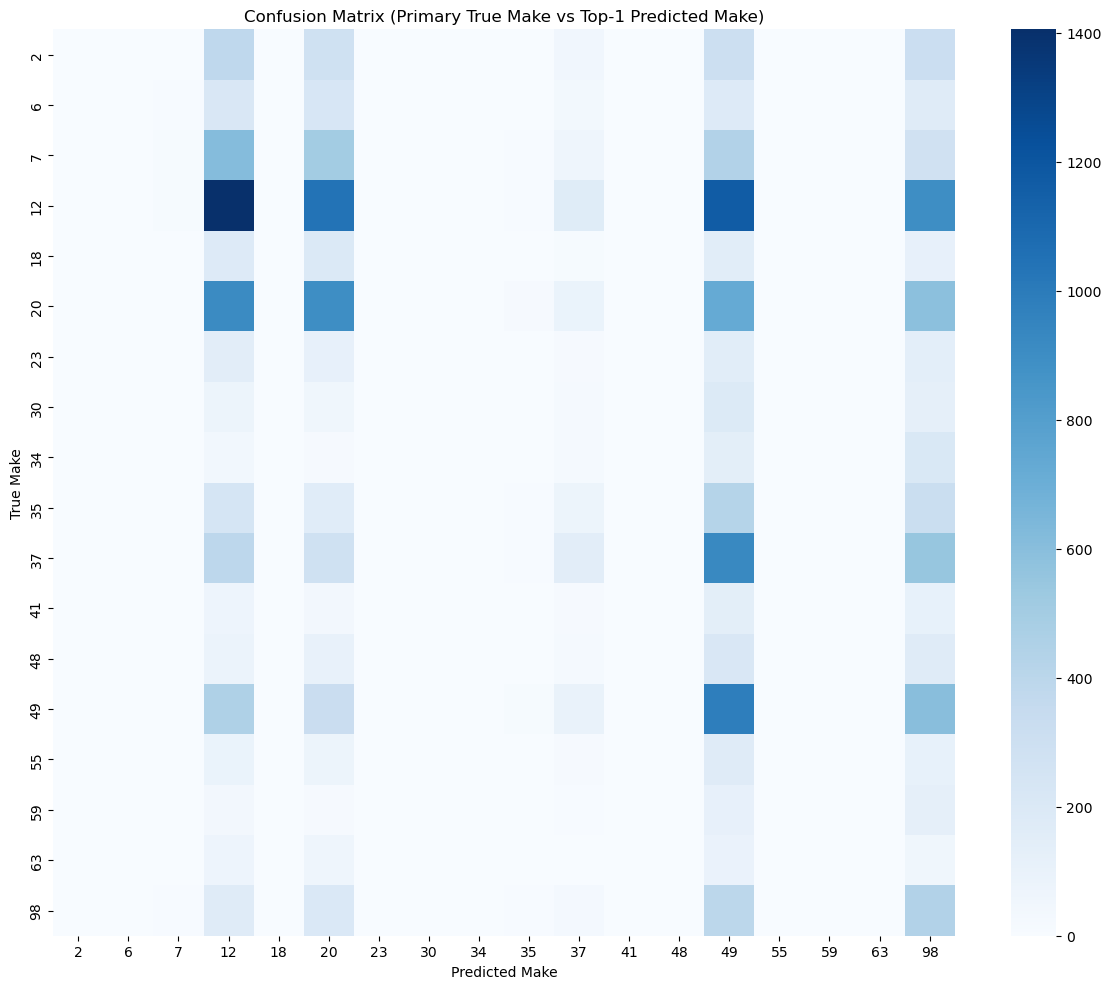

In [99]:
# Y_test is shape (n_samples, n_classes)
# mlb.classes_ holds the class names in the correct column order

true_primary_test = []

for i in range(Y_test.shape[0]):
    true_indices = np.where(Y_test[i] == 1)[0]       # all true makes for household i
    primary_idx = true_indices[0]                    # choose the first one
    true_primary_test.append(mlb.classes_[primary_idx])

# After Step 10 when you computed:
# top1_idx = np.argmax(probs_per_class, axis=1)
# top1_makes = mlb.classes_[top1_idx]

pred_primary_test = top1_makes

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_primary_test, pred_primary_test, labels=mlb.classes_)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(cm,
            annot=False,
            cmap="Blues",
            xticklabels=mlb.classes_,
            yticklabels=mlb.classes_)

plt.xlabel("Predicted Make")
plt.ylabel("True Make")
plt.title("Confusion Matrix (Primary True Make vs Top-1 Predicted Make)")
plt.tight_layout()
plt.show()